# Snapshot eval violins — held-out eval-config comparison across GEN snapshots

Compares **per-episode eval metrics** of multiple GEN snapshots across the **held-out
eval configs** their eval runs covered, drawn side by side at each config. A GEN
snapshot's eval run writes one result directory per infra config; **only the held-out
ones** — directory names ending in `_eval_<i>` (e.g. `battery_lin_cap_eval_1`) — are
considered here. Training-config directories (e.g. `battery_lin_cap_1..5`) are ignored.

The x-axis carries the eval configs (`eval_1`, `eval_2`, …); at each config the sources
are drawn as **dodged violins side by side** — one per snapshot — mirroring
`snapshot_eval_violins_seed_compare.ipynb` (which fans out over seeds instead).

Each **source** is one snapshot evaluated under one eval kind (plus a rule-based
strategy for `eval-rbc`):

| `eval-kind` | Run directory pattern | Producer | Per-eval-config CSV |
|---|---|---|---|
| `eval-ray` | `runs/eval_<ts>/` | Ray RLlib eval (`run_eval_ray.py`) | `eval_results/*_eval/<name>_eval_<i>/eval_*.csv` |
| `eval-sb` | `runs/eval_sb_<ts>/` | SB3 eval (`run_eval_sb.py`) | `eval_results/*_eval/<name>_eval_<i>/eval_*.csv` |
| `eval-rbc` | `runs/eval_rbc_<ts>/` | Rule-based eval (`run_eval_rule_based.py`) | `eval_results/*_rule_based/<strategy>/<name>_eval_<i>/episodes.csv` |

**Main input:** set `SOURCES` in the next cell.

In [ ]:
# --- Main input ---------------------------------------------------------------------
# The sources to compare side by side at each held-out eval config. Each source is one
# snapshot evaluated under one eval kind; at every eval config the x-axis draws one
# violin per source. Keys per entry:
#   path          snapshot dir (absolute, or relative to the repo root)
#   eval-kind     "eval-ray" | "eval-sb" | "eval-rbc" — which runs/eval_* dirs to use
#   label         short name shown in the legend and used as the per-config violin group
#   color         violin fill colour for this source
#   rbc-strategy  (eval-rbc only) which rule-based strategy to compare across configs

# SAC paths:
# snapshots/20260714_161830_gen_battery_lin_so_only_17kW
# snapshots/20260714_235241_gen_battery_lin_so_only_15kW
# snapshots/20260714_162614_gen_battery_lin_so_all
# snapshots/20260714_165943_gen_battery_lin_capacity_sampled

# PPO paths:
# snapshots/20260714_235342_gen_battery_lin_so_only_15kW_ppo
# snapshots/20260714_235444_gen_battery_lin_so_only_17kW_ppo
# snapshots/20260714_235542_gen_battery_lin_so_all_ppo
# snapshots/20260714_235647_gen_battery_lin_capacity_sampled_ppo

# Dreamer paths:
# snapshots/20260716_175201_gen_battery_lin_capacity_sampled_dreamerv3
# snapshots/20260718_140021_gen_battery_lin_capacity_sampled_dreamerv3_long
# snapshots/20260718_140503_gen_battery_lin_so_all_dreamerv3
# snapshots/20260718_141113_gen_battery_lin_so_only_17kW_dreamerv3
# snapshots/20260718_141218_gen_battery_lin_so_only_15kW_dreamerv3

SOURCES = [
    {
        "path": "snapshots/20260714_235444_gen_battery_lin_so_only_17kW_ppo",
        "eval-kind": "eval-ray",
        "label": "trained on 17 kWh",
        "color": "#75aef4",  # RL blue, matching snapshot_eval_violins.ipynb
    },
    {
        "path": "snapshots/20260714_235342_gen_battery_lin_so_only_15kW_ppo",
        "eval-kind": "eval-ray",
        "label": "trained on 15 kWh",
        "color": "#cc75f4",
    },
    {
        "path": "snapshots/20260714_235542_gen_battery_lin_so_all_ppo",
        "eval-kind": "eval-ray",
        "label": "5-way gen.",
        "color": "#f1bd2d",  # RL orange, matching snapshot_eval_violins.ipynb
    },
    {
        "path": "snapshots/20260714_235647_gen_battery_lin_capacity_sampled_ppo",
        "eval-kind": "eval-ray",
        "label": "gen. distribution",
        "color": "#89f0cc",  # green, matching snapshot_eval_violins.ipynb
    },
]

# Eval configs to exclude from every figure and table below (applied after discovery, to
# all sources). Leave empty to keep all discovered configs, e.g. EXCLUDE_EVAL_CFGS = ["eval_3"].
EXCLUDE_EVAL_CFGS: list[str] = []

# Optional display names for the x-axis ticks, keyed by the discovered `eval_<i>` label.
# Only affects the figures — tables and PDF filenames keep the `eval_<i>` keys. Configs
# not listed keep their default label, e.g. EVAL_CFG_LABELS = {"eval_1": "PV-heavy year"}.
EVAL_CFG_LABELS: dict[str, str] = {
	"eval_1": "BES: 12 kWh",
	"eval_2": "BES: 16 kWh",
	"eval_3": "BES: 22 kWh",
}

METRICS = ("total_reward", "cum_E_kWh", "cum_price_EUR")

In [2]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

EVAL_KINDS = ("eval-ray", "eval-sb", "eval-rbc")

# A held-out eval-config result directory ends in `_eval_<i>` (e.g. battery_lin_cap_eval_1);
# training-config directories (e.g. battery_lin_cap_3) do not match and are skipped.
_EVAL_CFG_DIR_PATTERN = re.compile(r"(?:^|_)eval_(\d+)$")


# Walk upwards from the cwd until the directory containing snapshots/ is found, so the
# notebook runs both from thesis_eval/ and from the repo root.
def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "snapshots").is_dir():
            return candidate
    raise FileNotFoundError("No 'snapshots/' directory found upwards of the cwd — run inside the repo.")


REPO_ROOT = _find_repo_root()


# Maps a runs/eval_* directory to its eval kind — mirrors the run-id scheme
# tools/snapshot/submit_snapshot.py builds from --kind.
def _run_dir_eval_kind(run_dir: Path) -> str:
    if run_dir.name.startswith("eval_rbc_"):
        return "eval-rbc"
    if run_dir.name.startswith("eval_sb_"):
        return "eval-sb"
    return "eval-ray"


# Discovers one record per (run, held-out eval config) CSV for a single source. The
# eval-config label is parsed from the per-config result directory name
# (`..._eval_<i>` -> `eval_<i>`); non-matching (training-config) directories are skipped.
def _discover_source_records(source: dict) -> list[dict]:
    eval_kind = source["eval-kind"]
    if eval_kind not in EVAL_KINDS:
        raise ValueError(f"'eval-kind' must be one of {EVAL_KINDS}, got {eval_kind!r}")

    snapshot_dir = Path(source["path"])
    snapshot_dir = snapshot_dir if snapshot_dir.is_absolute() else REPO_ROOT / snapshot_dir
    if not snapshot_dir.is_dir():
        raise FileNotFoundError(f"Snapshot directory not found: {snapshot_dir}")

    run_dirs = [
        run_dir for run_dir in sorted((snapshot_dir / "runs").glob("eval_*"))
        if _run_dir_eval_kind(run_dir) == eval_kind
    ]
    if not run_dirs:
        raise FileNotFoundError(f"No '{eval_kind}' run directories found under {snapshot_dir / 'runs'}")

    records = []
    for run_dir in run_dirs:
        if eval_kind == "eval-rbc":
            csv_paths = sorted(run_dir.glob("eval_results/*_rule_based/*/*/episodes.csv"))
            strategies = sorted({csv_path.parent.parent.name for csv_path in csv_paths})
            strategy = source.get("rbc-strategy")
            if strategy is None and len(strategies) > 1:
                raise ValueError(
                    f"Source '{source['label']}': multiple rule-based strategies {strategies} under "
                    f"{run_dir.name} — set 'rbc-strategy' to pick one."
                )
            csv_paths = [csv_path for csv_path in csv_paths
                        if strategy is None or csv_path.parent.parent.name == strategy]
        else:
            csv_paths = sorted(run_dir.glob("eval_results/*_eval/*/eval_*.csv"))
        for csv_path in csv_paths:
            match = _EVAL_CFG_DIR_PATTERN.search(csv_path.parent.name)
            if match is None:
                continue  # training-config result dir — not a held-out eval config
            records.append({
                "source": source["label"], "snapshot_dir": snapshot_dir, "run": run_dir.name,
                "eval_cfg": f"eval_{match.group(1)}", "eval_index": int(match.group(1)),
                "cfg_dir": csv_path.parent.name, "csv": csv_path,
            })
    if not records:
        raise FileNotFoundError(
            f"No held-out eval-config CSVs (*_eval_<i>) discovered for source '{source['label']}' "
            f"({eval_kind}) under {snapshot_dir}"
        )
    return records


source_labels = [source["label"] for source in SOURCES]
if len(source_labels) != len(set(source_labels)):
    raise ValueError(f"Every source needs a unique 'label' (it names the per-config violin group); got {source_labels}")
source_palette = {source["label"]: source["color"] for source in SOURCES}

eval_records: list[dict] = []
for source in SOURCES:
    eval_records.extend(_discover_source_records(source))

print(f"Repo root: {REPO_ROOT}")
for source in SOURCES:
    records = [record for record in eval_records if record["source"] == source["label"]]
    strategy = f", strategy={source.get('rbc-strategy')}" if source["eval-kind"] == "eval-rbc" else ""
    print(f"\nSource '{source['label']}' ({source['eval-kind']}{strategy}): {source['path']}")
    for record in sorted(records, key=lambda record: (record["eval_index"], record["run"])):
        print(f"  {record['eval_cfg']:>8}  <-  {record['run']} / {record['cfg_dir']}")

Repo root: /hkfs/home/haicore/iai/dj0397/AdvBuildingGym

Source 'trained on 17 kWh' (eval-ray): snapshots/20260714_235444_gen_battery_lin_so_only_17kW_ppo
    eval_1  <-  eval_20260715_101619 / battery_lin_cap_eval_1
    eval_2  <-  eval_20260715_101619 / battery_lin_cap_eval_2
    eval_3  <-  eval_20260715_101619 / battery_lin_cap_eval_3

Source 'trained on 15 kWh' (eval-ray): snapshots/20260714_235342_gen_battery_lin_so_only_15kW_ppo
    eval_1  <-  eval_20260715_101616 / battery_lin_cap_eval_1
    eval_2  <-  eval_20260715_101616 / battery_lin_cap_eval_2
    eval_3  <-  eval_20260715_101616 / battery_lin_cap_eval_3

Source '5-way gen.' (eval-ray): snapshots/20260714_235542_gen_battery_lin_so_all_ppo
    eval_1  <-  eval_20260715_101621 / battery_lin_cap_eval_1
    eval_2  <-  eval_20260715_101621 / battery_lin_cap_eval_2
    eval_3  <-  eval_20260715_101621 / battery_lin_cap_eval_3

Source 'gen. distribution' (eval-ray): snapshots/20260714_235647_gen_battery_lin_capacity_sampled_ppo

## Align the eval configs

One violin group per (source, eval config). The x-axis is the numerically sorted union
of the `eval_<i>` labels seen across the sources (after dropping any in
`EXCLUDE_EVAL_CFGS`); a warning is printed if the sources do not cover exactly the same
configs — seaborn simply leaves a gap where a source has no results for a config. A
source with multiple CSVs for one config (several eval runs or checkpoints) pools their
episodes into a single violin, with a warning.

In [3]:
# Drop any explicitly excluded eval configs (EXCLUDE_EVAL_CFGS) from every figure and table below.
_excluded_set = set(EXCLUDE_EVAL_CFGS)
_dropped = sorted({record["eval_cfg"] for record in eval_records if record["eval_cfg"] in _excluded_set})
if _dropped:
    print(f"Excluding eval config(s) {_dropped} (EXCLUDE_EVAL_CFGS).")
eval_records = [record for record in eval_records if record["eval_cfg"] not in _excluded_set]
if not eval_records:
    raise ValueError(f"EXCLUDE_EVAL_CFGS={EXCLUDE_EVAL_CFGS} removed every discovered CSV — nothing left to plot.")

# One violin per (source, eval config): flag sources with multiple CSVs for one config
# (their episodes would pool into a single violin for that config).
for source in SOURCES:
    cfgs = [record["eval_cfg"] for record in eval_records if record["source"] == source["label"]]
    duplicates = sorted({cfg for cfg in cfgs if cfgs.count(cfg) > 1})
    if duplicates:
        print(f"WARNING: source '{source['label']}' has multiple CSVs for eval config(s) {duplicates} — "
              "their episodes are pooled into one violin per config.")

# x-axis: the numerically sorted union of eval configs; warn where a source does not cover the union.
eval_cfg_order = [f"eval_{index}" for index in sorted({record["eval_index"] for record in eval_records})]
for source in SOURCES:
    source_cfgs = {record["eval_cfg"] for record in eval_records if record["source"] == source["label"]}
    missing = [cfg for cfg in eval_cfg_order if cfg not in source_cfgs]
    if missing:
        print(f"WARNING: source '{source['label']}' has no results for eval config(s) {missing} — "
              "those slots show only the other sources' violins.")


def _display_path(csv_path: Path) -> str:
    try:
        return str(csv_path.relative_to(REPO_ROOT))
    except ValueError:
        return str(csv_path)


pd.DataFrame(
    {"source": record["source"], "eval_cfg": record["eval_cfg"], "run": record["run"], "csv": _display_path(record["csv"])}
    for record in sorted(eval_records, key=lambda record: (record["eval_index"], source_labels.index(record["source"])))
)

,source,eval_cfg,run,csv
0,trained on 17 kWh,eval_1,eval_20260715_101619,snapshots/20260714_235444_gen_battery_lin_so_o...
1,trained on 15 kWh,eval_1,eval_20260715_101616,snapshots/20260714_235342_gen_battery_lin_so_o...
2,5-way gen.,eval_1,eval_20260715_101621,snapshots/20260714_235542_gen_battery_lin_so_a...
3,gen. distribution,eval_1,eval_20260715_101623,snapshots/20260714_235647_gen_battery_lin_capa...
4,trained on 17 kWh,eval_2,eval_20260715_101619,snapshots/20260714_235444_gen_battery_lin_so_o...
5,trained on 15 kWh,eval_2,eval_20260715_101616,snapshots/20260714_235342_gen_battery_lin_so_o...
6,5-way gen.,eval_2,eval_20260715_101621,snapshots/20260714_235542_gen_battery_lin_so_a...
7,gen. distribution,eval_2,eval_20260715_101623,snapshots/20260714_235647_gen_battery_lin_capa...
8,trained on 17 kWh,eval_3,eval_20260715_101619,snapshots/20260714_235444_gen_battery_lin_so_o...
9,trained on 15 kWh,eval_3,eval_20260715_101616,snapshots/20260714_235342_gen_battery_lin_so_o...


## Load per-episode metrics

Every CSV is concatenated into one long-format frame, one row per episode, tagged with
its `source` and `eval_cfg`. A CSV missing a metric column is simply absent from that
metric's figure.

In [4]:
frames = []
for record in eval_records:
    csv_frame = pd.read_csv(record["csv"])
    present = [metric for metric in METRICS if metric in csv_frame.columns]
    missing = [metric for metric in METRICS if metric not in csv_frame.columns]
    if missing:
        print(f"note: source '{record['source']}' {record['eval_cfg']} lacks {missing} — skipped in those figures")
    frame = csv_frame[present].copy()
    frame["source"] = record["source"]
    frame["eval_cfg"] = record["eval_cfg"]
    frames.append(frame)

episodes = pd.concat(frames, ignore_index=True)
present_metrics = [metric for metric in METRICS if metric in episodes.columns]

episodes.groupby(["eval_cfg", "source"], sort=True).agg(
    episodes=("eval_cfg", "size"),
    **{f"mean_{metric}": (metric, "mean") for metric in present_metrics},
)

episodes  mean_total_reward  mean_cum_E_kWh  \
eval_cfg source                                                           
eval_1   5-way gen.               10          13.024595       49.192031   
         gen. distribution        10          13.082061       49.192031   
         trained on 15 kWh        10          13.083414       49.192031   
         trained on 17 kWh        10          13.282687       49.192031   
eval_2   5-way gen.               10          15.245878       49.946428   
         gen. distribution        10          15.192412       49.946428   
         trained on 15 kWh        10          15.222501       49.946428   
         trained on 17 kWh        10          15.453426       49.946428   
eval_3   5-way gen.               10          18.374406       51.078022   
         gen. distribution        10          18.204692       51.078022   
         trained on 15 kWh        10          17.547855       51.078022   
         trained on 17 kWh        10          17.542588       51.078022   

                            mean_cum_price_EUR  
eval_cfg source                                 
eval_1   5-way gen.                  -3.881797  
         gen. distribution           -3.869723  
         trained on 15 kWh           -3.767231  
         trained on 17 kWh           -3.848149  
eval_2   5-way gen.                  -4.523258  
         gen. distribution           -4.458690  
         trained on 15 kWh           -4.386307  
         trained on 17 kWh           -4.460369  
eval_3   5-way gen.                  -5.391240  
         gen. distribution           -5.286007  
         trained on 15 kWh           -5.130842  
         trained on 17 kWh           -5.037178

## Violin plots

At each held-out eval config the sources are drawn as **dodged violins side by side**
(coloured by the `SOURCES` colours), separated by `VIOLIN_GAP`; individual episodes are
overlaid as dodged dots. Each violin carries two stat markers: **mean** (red dot) and
**median** (narrow dashed line). The x ticks default to the `eval_<i>` labels and can be
renamed via `EVAL_CFG_LABELS` (main-input cell). The figures carry **no title**
(thesis-ready). Each figure is saved into **every** source snapshot's `stat/` directory
as `violin_<metric>_evalcfg_compare_<src1>_vs_<src2>[...].pdf`.

In [5]:
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid", context="notebook")

METRIC_LABELS = {
    "total_reward": "Total reward per episode",
    "cum_E_kWh": "Cumulative energy consumption [kWh]",
    "cum_price_EUR": "Cumulative energy price [EUR]",
}

# Stat markers drawn on top of each violin (replaces seaborn's faint inner box)
MEAN_COLOR = "#e34948"  # red dot
MEDIAN_COLOR = "#1a1a19"  # narrow dashed line
MEDIAN_DASH = (0, (4, 2))

DODGE_WIDTH = 0.8  # seaborn violinplot default `width` — the per-config slot the sources share
VIOLIN_GAP = 0.2   # shrink factor on each dodged violin (seaborn `gap`) — space between neighbours
_cfg_position = {cfg: index for index, cfg in enumerate(eval_cfg_order)}


# Centre offset of a source's dodged violin within an eval config's slot, so the stat markers
# land on the exact violin seaborn draws for that (config, source). Matches seaborn's even hue
# split; `gap` shrinks each violin around this same centre, so the offset is gap-independent.
def _dodge_offset(source_label: str) -> float:
    hue_index = source_labels.index(source_label)
    return DODGE_WIDTH * ((hue_index + 0.5) / len(source_labels) - 0.5)


# Overlays each dodged violin's mean (red dot) and median (narrow dashed line).
def _draw_stat_markers(ax, data: pd.DataFrame, metric: str) -> None:
    half_width = 0.9 * (1 - VIOLIN_GAP) * (DODGE_WIDTH / len(source_labels)) / 2
    stats = data.groupby(["eval_cfg", "source"])[metric].agg(["mean", "median"])
    for (eval_cfg, source), row in stats.iterrows():
        if eval_cfg not in _cfg_position or source not in source_labels:
            continue
        x_position = _cfg_position[eval_cfg] + _dodge_offset(source)
        ax.hlines(
            row["median"], x_position - half_width, x_position + half_width,
            color=MEDIAN_COLOR, linewidth=0.9, linestyle=MEDIAN_DASH, zorder=5,
        )
        ax.scatter(
            x_position, row["mean"],
            color=MEAN_COLOR, s=18, edgecolor="white", linewidth=0.5, zorder=6,
        )


_compare_tag = re.sub(r"\W+", "_", "_vs_".join(source_labels)).strip("_").lower()
_snapshot_dirs = sorted({record["snapshot_dir"] for record in eval_records}, key=str)


# Draws one violin per source at each held-out eval config for `metric` (no figure
# title) and exports the figure as a PDF into every source snapshot's stat/.
def violin_for_metric(metric: str) -> None:
    data = episodes.dropna(subset=[metric]) if metric in episodes.columns else episodes.iloc[0:0]
    if data.empty:
        print(f"no data for '{metric}' — figure skipped")
        return

    figure_width = max(8.0, 0.9 * len(eval_cfg_order) * len(source_labels))
    fig, ax = plt.subplots(figsize=(figure_width, 5.0))
    sns.violinplot(
        data=data,
        x="eval_cfg",
        y=metric,
        hue="source",
        order=eval_cfg_order,
        hue_order=source_labels,
        palette=source_palette,
        dodge=True,  # one violin per source, side by side per eval config
        gap=VIOLIN_GAP,  # space between the dodged violins
        density_norm="area",
        inner=None,  # the stat markers below replace seaborn's faint inner box
        linewidth=1.0,
        saturation=1.0,
        ax=ax,
    )
    sns.stripplot(
        data=data, x="eval_cfg", y=metric, hue="source",
        order=eval_cfg_order, hue_order=source_labels, dodge=True,
        palette={source: "0.1" for source in source_labels},
        size=3, alpha=0.6, jitter=0.08, legend=False, ax=ax,
    )
    _draw_stat_markers(ax, data, metric)

    ax.set_xlabel("Eval configs")
    # Rename the x ticks via EVAL_CFG_LABELS (display only — data keys stay `eval_<i>`).
    ax.set_xticks(range(len(eval_cfg_order)), [EVAL_CFG_LABELS.get(cfg, cfg) for cfg in eval_cfg_order])
    ax.set_ylabel(METRIC_LABELS.get(metric, metric))
    ax.grid(axis="x", visible=False)

    # Legend: the source colours seaborn built + the mean/median stat markers, outside the axes.
    source_handles, source_legend_labels = ax.get_legend_handles_labels()
    stat_handles = [
        Line2D([], [], color=MEAN_COLOR, marker="o", linestyle="none", markersize=5,
               markeredgewidth=0.5, label="mean"),
        Line2D([], [], color=MEDIAN_COLOR, linewidth=0.9, linestyle=MEDIAN_DASH, label="median"),
    ]
    ax.legend(
        handles=source_handles + stat_handles,
        labels=source_legend_labels + [handle.get_label() for handle in stat_handles],
        title="", frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0.0,
    )
    sns.despine(ax=ax)
    fig.tight_layout()

    for snapshot_dir in _snapshot_dirs:
        stat_dir = snapshot_dir / "stat"
        stat_dir.mkdir(parents=True, exist_ok=True)
        pdf_path = stat_dir / f"violin_{metric}_evalcfg_compare_{_compare_tag}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")
        print(f"saved {pdf_path}")
    plt.show()

saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260714_235342_gen_battery_lin_so_only_15kW_ppo/stat/violin_total_reward_evalcfg_compare_trained_on_17_kwh_vs_trained_on_15_kwh_vs_5_way_gen__vs_gen_distribution.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260714_235444_gen_battery_lin_so_only_17kW_ppo/stat/violin_total_reward_evalcfg_compare_trained_on_17_kwh_vs_trained_on_15_kwh_vs_5_way_gen__vs_gen_distribution.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260714_235542_gen_battery_lin_so_all_ppo/stat/violin_total_reward_evalcfg_compare_trained_on_17_kwh_vs_trained_on_15_kwh_vs_5_way_gen__vs_gen_distribution.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260714_235647_gen_battery_lin_capacity_sampled_ppo/stat/violin_total_reward_evalcfg_compare_trained_on_17_kwh_vs_trained_on_15_kwh_vs_5_way_gen__vs_gen_distribution.pdf


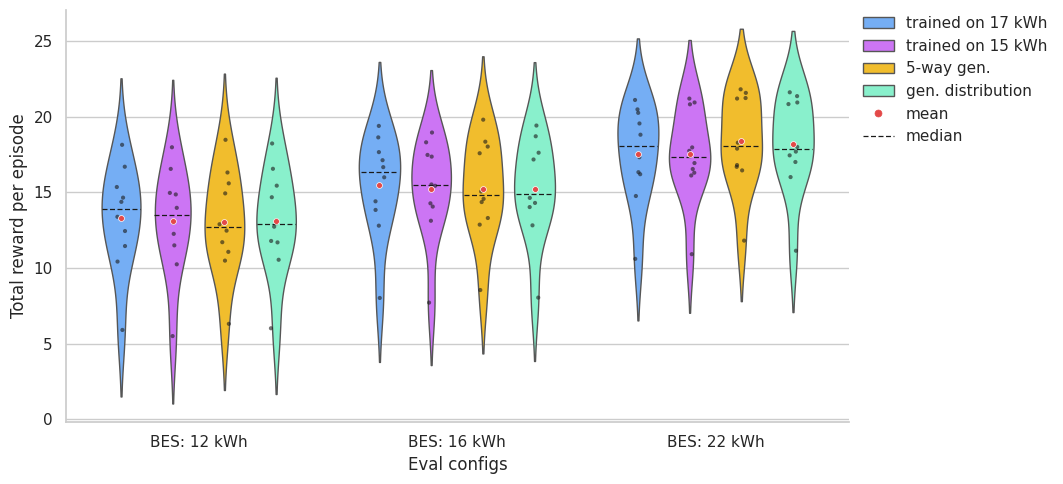

In [6]:
violin_for_metric("total_reward")

saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260714_235342_gen_battery_lin_so_only_15kW_ppo/stat/violin_cum_E_kWh_evalcfg_compare_trained_on_17_kwh_vs_trained_on_15_kwh_vs_5_way_gen__vs_gen_distribution.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260714_235444_gen_battery_lin_so_only_17kW_ppo/stat/violin_cum_E_kWh_evalcfg_compare_trained_on_17_kwh_vs_trained_on_15_kwh_vs_5_way_gen__vs_gen_distribution.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260714_235542_gen_battery_lin_so_all_ppo/stat/violin_cum_E_kWh_evalcfg_compare_trained_on_17_kwh_vs_trained_on_15_kwh_vs_5_way_gen__vs_gen_distribution.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260714_235647_gen_battery_lin_capacity_sampled_ppo/stat/violin_cum_E_kWh_evalcfg_compare_trained_on_17_kwh_vs_trained_on_15_kwh_vs_5_way_gen__vs_gen_distribution.pdf


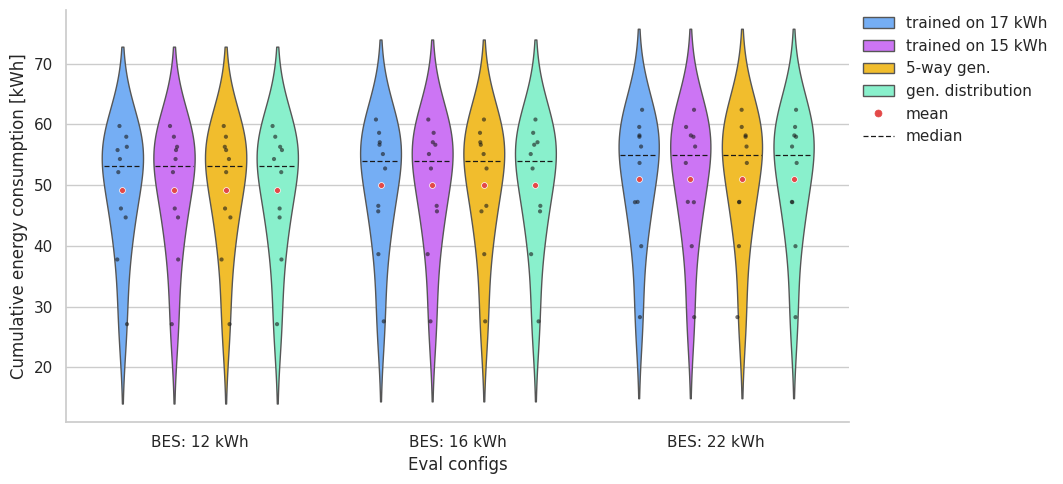

In [7]:
violin_for_metric("cum_E_kWh")

saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260714_235342_gen_battery_lin_so_only_15kW_ppo/stat/violin_cum_price_EUR_evalcfg_compare_trained_on_17_kwh_vs_trained_on_15_kwh_vs_5_way_gen__vs_gen_distribution.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260714_235444_gen_battery_lin_so_only_17kW_ppo/stat/violin_cum_price_EUR_evalcfg_compare_trained_on_17_kwh_vs_trained_on_15_kwh_vs_5_way_gen__vs_gen_distribution.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260714_235542_gen_battery_lin_so_all_ppo/stat/violin_cum_price_EUR_evalcfg_compare_trained_on_17_kwh_vs_trained_on_15_kwh_vs_5_way_gen__vs_gen_distribution.pdf
saved /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260714_235647_gen_battery_lin_capacity_sampled_ppo/stat/violin_cum_price_EUR_evalcfg_compare_trained_on_17_kwh_vs_trained_on_15_kwh_vs_5_way_gen__vs_gen_distribution.pdf


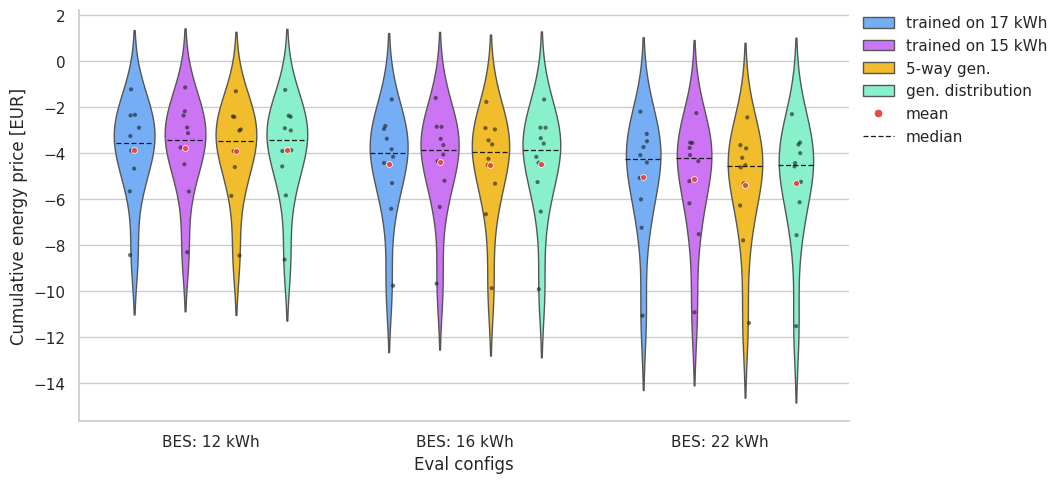

In [8]:
violin_for_metric("cum_price_EUR")

## Variance across eval configs, per source

For each source, the metric mean is first taken within each held-out eval config, then
aggregated (`mean` / `std` / `min` / `max`) across the configs — a small `std` means
that snapshot's per-episode metrics generalise consistently across the held-out
configs. Comparing the sources' `std` shows which generalises the most robustly.

In [9]:
present_metrics = [metric for metric in METRICS if metric in episodes.columns]
cfg_means = episodes.groupby(["source", "eval_cfg"])[present_metrics].mean()
cfg_means.groupby("source").agg(["mean", "std", "min", "max"])

total_reward                                 cum_E_kWh  \
                          mean       std        min        max      mean   
source                                                                     
5-way gen.           15.548293  2.687696  13.024595  18.374406  50.07216   
gen. distribution    15.493055  2.574515  13.082061  18.204692  50.07216   
trained on 15 kWh    15.284590  2.232868  13.083414  17.547855  50.07216   
trained on 17 kWh    15.426234  2.130080  13.282687  17.542588  50.07216   

                                                  cum_price_EUR            \
                        std        min        max          mean       std   
source                                                                      
5-way gen.         0.949261  49.192031  51.078022     -4.598765  0.757549   
gen. distribution  0.949261  49.192031  51.078022     -4.538140  0.711477   
trained on 15 kWh  0.949261  49.192031  51.078022     -4.428127  0.682767   
trained on 17 kWh  0.949261  49.192031  51.078022     -4.448565  0.594602   

                                       
                        min       max  
source                                 
5-way gen.        -5.391240 -3.881797  
gen. distribution -5.286007 -3.869723  
trained on 15 kWh -5.130842 -3.767231  
trained on 17 kWh -5.037178 -3.848149

## Per-violin statistics

One row per (eval config, source) — i.e. per violin drawn above — computed over that
violin's eval episodes: episode `count`, `mean` (the red dot), `std`, `median` (the
dashed line), `min` and `max` for every metric. Rows follow the plot order: x-axis
configs first, then the `SOURCES` hue order within each config.

In [10]:
present_metrics = [metric for metric in METRICS if metric in episodes.columns]
violin_stats = episodes.groupby(["eval_cfg", "source"])[present_metrics].agg(
    ["mean", "std", "median", "min", "max"]
)
# Match the plot order: x-axis configs (numeric), then the SOURCES hue order per config.
violin_stats = violin_stats.reindex(eval_cfg_order, level="eval_cfg").reindex(source_labels, level="source")
violin_stats

total_reward                                  \
                                   mean       std     median        min   
eval_cfg source                                                           
eval_1   trained on 17 kWh    13.282687  3.484247  13.879615   5.905861   
         trained on 15 kWh    13.083414  3.531892  13.487573   5.500584   
         5-way gen.           13.024595  3.466700  12.680930   6.309796   
         gen. distribution    13.082061  3.444551  12.935603   6.017173   
eval_2   trained on 17 kWh    15.453426  3.350937  16.330224   8.019709   
         trained on 15 kWh    15.222501  3.271057  15.478193   7.711626   
         5-way gen.           15.245878  3.320584  14.811844   8.543432   
         gen. distribution    15.192412  3.320212  14.908423   8.043215   
eval_3   trained on 17 kWh    17.542588  3.224162  18.066700  10.604636   
         trained on 15 kWh    17.547855  3.068666  17.340341  10.914722   
         5-way gen.           18.374406  3.171989  18.086238  11.810404   
         gen. distribution    18.204692  3.214652  17.847374  11.141521   

                                       cum_E_kWh                        \
                                  max       mean        std     median   
eval_cfg source                                                          
eval_1   trained on 17 kWh  18.142499  49.192031  10.356775  53.217811   
         trained on 15 kWh  17.980350  49.192031  10.356775  53.217811   
         5-way gen.         18.472908  49.192031  10.356775  53.217811   
         gen. distribution  18.230550  49.192031  10.356775  53.217811   
eval_2   trained on 17 kWh  19.391891  49.946428  10.443800  53.932453   
         trained on 15 kWh  18.953871  49.946428  10.443800  53.932453   
         5-way gen.         19.803645  49.946428  10.443800  53.932453   
         gen. distribution  19.416089  49.946428  10.443800  53.932453   
eval_3   trained on 17 kWh  21.105757  51.078022  10.581166  55.004415   
         trained on 15 kWh  21.198185  51.078022  10.581166  55.004415   
         5-way gen.         21.811574  51.078022  10.581166  55.004415   
         gen. distribution  21.613516  51.078022  10.581166  55.004415   

                                                 cum_price_EUR            \
                                  min        max          mean       std   
eval_cfg source                                                            
eval_1   trained on 17 kWh  27.102668  59.738004     -3.848149  2.044610   
         trained on 15 kWh  27.102668  59.738004     -3.767231  2.036198   
         5-way gen.         27.102668  59.738004     -3.881797  2.049340   
         gen. distribution  27.102668  59.738004     -3.869723  2.104492   
eval_2   trained on 17 kWh  27.564449  60.804940     -4.460369  2.289078   
         trained on 15 kWh  27.564449  60.804940     -4.386307  2.274399   
         5-way gen.         27.564449  60.804940     -4.523258  2.320273   
         gen. distribution  27.564449  60.804940     -4.458690  2.346006   
eval_3   trained on 17 kWh  28.257121  62.405343     -5.037178  2.563811   
         trained on 15 kWh  28.257121  62.405343     -5.130842  2.519295   
         5-way gen.         28.257121  62.405343     -5.391240  2.571287   
         gen. distribution  28.257121  62.405343     -5.286007  2.632770   

                                                           
                              median        min       max  
eval_cfg source                                            
eval_1   trained on 17 kWh -3.545300  -8.424150 -1.217296  
         trained on 15 kWh -3.432092  -8.298259 -1.133762  
         5-way gen.        -3.455183  -8.441124 -1.300554  
         gen. distribution -3.433987  -8.617693 -1.240240  
eval_2   trained on 17 kWh -3.983512  -9.753332 -1.652996  
         trained on 15 kWh -3.846132  -9.663171 -1.589495  
         5-way gen.        -3.922208  -9.862391 -1.760944  
         gen. distribution -3.862910  -9.907040 -